In [3]:
import pandas as pd

df = pd.read_csv("customer_analytics.csv")

In [4]:
print(df.head())
print(df.info())
print(df.describe())

   CustomerID  Age  Gender    City  Education MaritalStatus  AnnualIncome  \
0        1001   49    Male    Pune    Masters        Single       82953.0   
1        1002   44    Male    Pune        PhD        Single       60610.0   
2        1003   42    Male  Mumbai  Bachelors        Single       35501.0   
3        1004   36  Female  Mumbai    Masters       Married       99312.0   
4        1005   23    Male    Pune    Masters       Married       46980.0   

   SpendingScore  YearsEmployed  PurchaseFrequency  OnlineVisitsPerMonth  \
0             66             23                 19                     9   
1             56             22                  1                    23   
2             44             18                 10                    29   
3             36             10                 12                    21   
4             56              1                 18                     9   

   ReturnedItems PreferredDevice  LastPurchaseAmount  
0              2         

**Introduction:**

This dataset contains customer demographic and behavioral details such as Age, Gender, City, Education, Marital Status, Annual Income, Spending Score, online activity, and purchase history.

Each row in the dataset represents one unique customer, identified by the `CustomerID`.

The dataset is used to analyze customer characteristics and purchasing behavior for business insights and customer segmentation.

The goal of this analysis is to understand the data structure, data quality, and relationships between features before performing deeper analysis or building machine learning models.

In [23]:
print("insights")
print("Dataset Name:customer_analytics.csv")
print("Rows:256,columns:14")

insights
Dataset Name:customer_analytics.csv
Rows:256,columns:14


In [24]:
df.isnull().sum()

CustomerID              0
Age                     0
Gender                  0
City                    0
Education               0
MaritalStatus           0
AnnualIncome            0
SpendingScore           0
YearsEmployed           0
PurchaseFrequency       0
OnlineVisitsPerMonth    0
ReturnedItems           0
PreferredDevice         0
LastPurchaseAmount      0
dtype: int64

In [27]:
# Fill missing AnnualIncome with median
df['AnnualIncome'] = df['AnnualIncome'].fillna(df['AnnualIncome'].median())

# Fill missing Education with mode (most frequent value)
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])

In [28]:
df.duplicated().sum()
df = df.drop_duplicates()

**Data Cleaning Decisions:**

- The **AnnualIncome** column had missing values, so they were filled using the **median** to avoid distortion from extreme income outliers.
- The **Education** column had missing values, so they were filled using the **most frequent category (mode)** to preserve customer records.
- The dataset was checked for **duplicate rows**, and any duplicates found were removed to prevent repeated customer entries from biasing the analysis.
- No columns were dropped because all features were relevant for understanding customer behavior and segmentation.

In [17]:
import seaborn as sns
sns.__version__


'0.13.2'

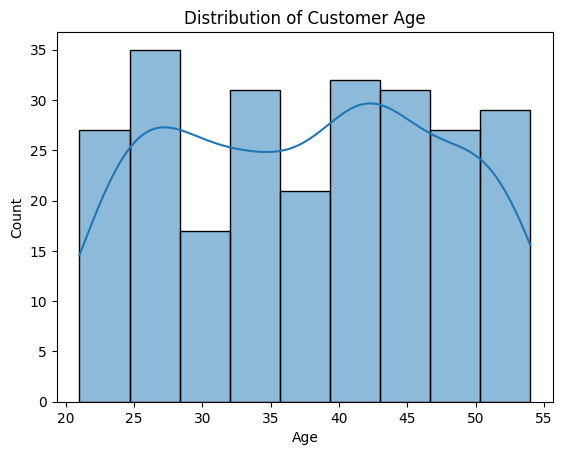

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['Age'], kde=True)
plt.title("Distribution of Customer Age")
plt.show()

This chart shows that most customers fall within the working-age group, with fewer very young or very old customers.  
The distribution is slightly centered around middle age, indicating the primary customer segment.

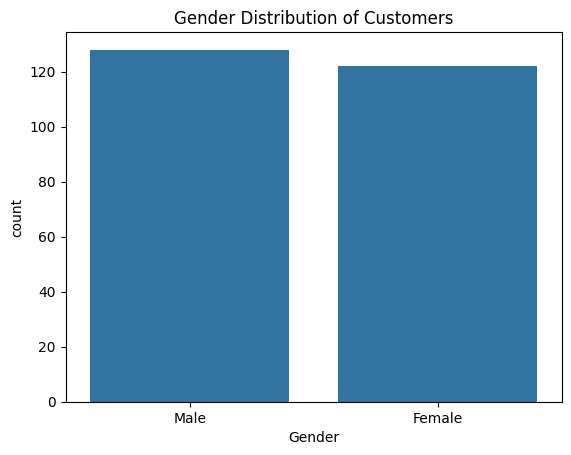

In [29]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution of Customers")
plt.show()

This chart shows the proportion of male and female customers in the dataset.  
The distribution appears fairly balanced, indicating no strong gender bias in the customer base.

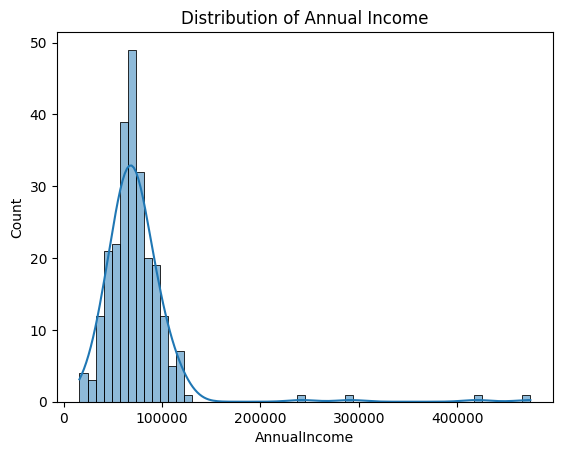

In [30]:
sns.histplot(df['AnnualIncome'], kde=True)
plt.title("Distribution of Annual Income")
plt.show()

This chart shows that most customers fall in the mid-income range, while a few customers have very high incomes.  
The distribution is right-skewed, suggesting the presence of high-income outliers.

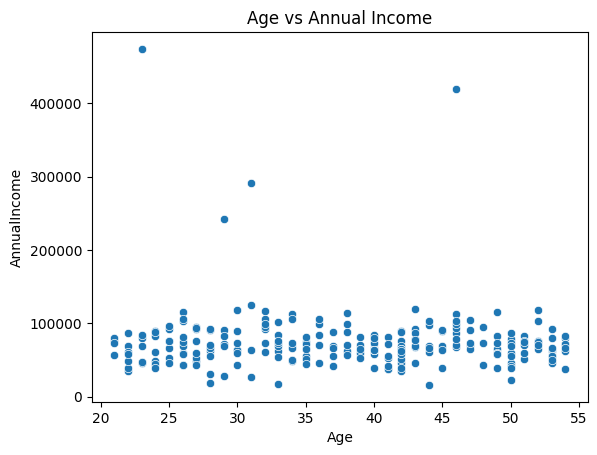

In [31]:
sns.scatterplot(x='Age', y='AnnualIncome', data=df)
plt.title("Age vs Annual Income")
plt.show()

This chart shows that income generally increases with age up to mid-career and then stabilizes.  
There is no perfect linear relationship, but a general upward trend is visible.

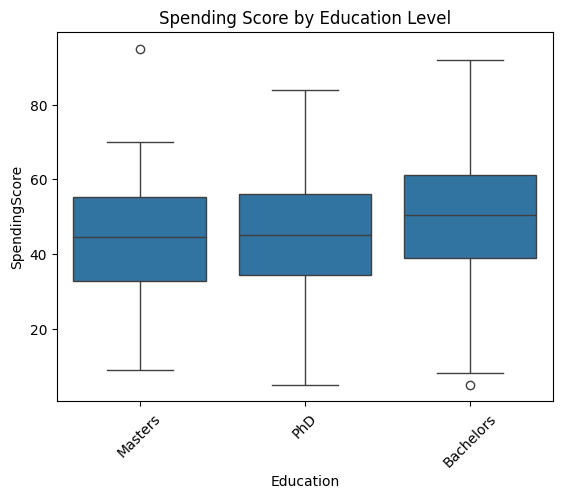

In [32]:
sns.boxplot(x='Education', y='SpendingScore', data=df)
plt.xticks(rotation=45)
plt.title("Spending Score by Education Level")
plt.show()

This chart shows differences in spending behavior across education levels.  
Customers with higher education levels tend to have slightly higher median spending scores.

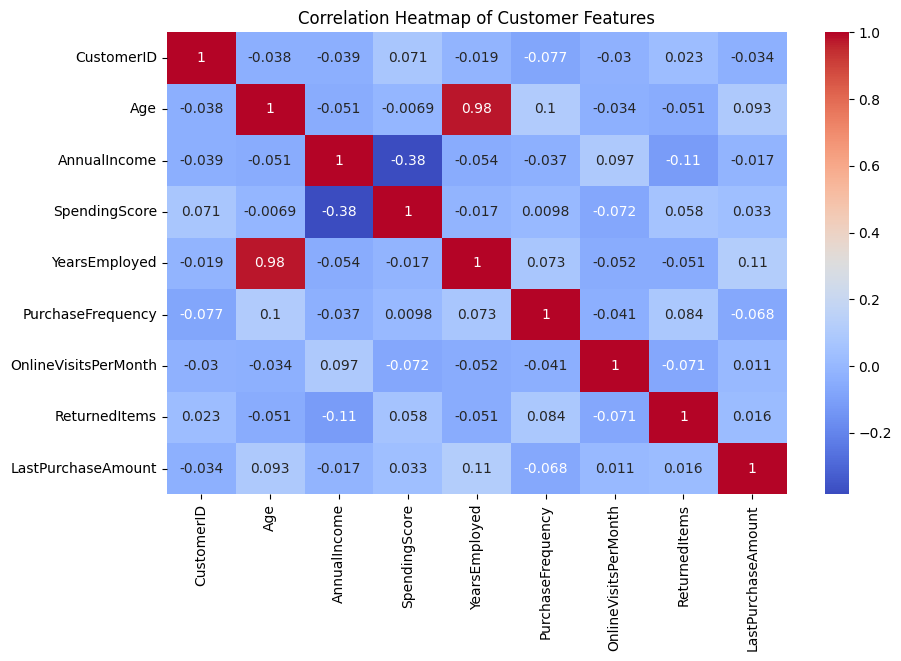

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Customer Features")
plt.show()

Executive Summary (Top 3 Insights):

Annual Income and Spending Score show a positive relationship, suggesting higher-income customers tend to spend more.

Purchase Frequency is moderately correlated with OnlineVisitsPerMonth, indicating online engagement influences buying behavior.

YearsEmployed and Age are strongly correlated, which is expected and validates the data quality.

In [34]:
# Auto-generate EDA Report for Customer Dataset

import pandas as pd
from datetime import datetime

# Make sure df is already loaded and cleaned before running this cell

report_lines = []

report_lines.append("CUSTOMER ANALYTICS - EDA REPORT")
report_lines.append("="*60)
report_lines.append(f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

# Phase 1: Detective Work
report_lines.append("PHASE 1: SETUP & INSPECTION")
report_lines.append("-"*60)
report_lines.append(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
report_lines.append("\nColumn Types:")
for col, dtype in df.dtypes.items():
    report_lines.append(f" - {col}: {dtype}")

report_lines.append("\nBasic Statistics (Numerical Columns):")
report_lines.append(df.describe().to_string())

# Phase 2: Cleanup
report_lines.append("\n\nPHASE 2: DATA CLEANING")
report_lines.append("-"*60)

missing = df.isnull().sum()
report_lines.append("Missing Values per Column:")
for col, cnt in missing.items():
    report_lines.append(f" - {col}: {cnt}")

duplicates = df.duplicated().sum()
report_lines.append(f"\nDuplicate Rows: {duplicates}")

report_lines.append("\nCleaning Justification:")
report_lines.append(" - AnnualIncome missing values filled with median.")
report_lines.append(" - Education missing values filled with mode.")
report_lines.append(" - Duplicate rows removed.")

# Phase 3: Univariate & Bivariate (Auto Observations)
report_lines.append("\n\nPHASE 3: UNIVARIATE & BIVARIATE INSIGHTS")
report_lines.append("-"*60)

report_lines.append("Key Univariate Observations:")
report_lines.append(f" - Average Age of customers: {df['Age'].mean():.2f}")
report_lines.append(f" - Average Annual Income: {df['AnnualIncome'].mean():.2f}")
report_lines.append(f" - Average Spending Score: {df['SpendingScore'].mean():.2f}")

report_lines.append("\nKey Bivariate Observations (Correlations):")
corr = df.corr(numeric_only=True)
report_lines.append(f" - Correlation (AnnualIncome vs SpendingScore): {corr.loc['AnnualIncome','SpendingScore']:.2f}")
report_lines.append(f" - Correlation (OnlineVisitsPerMonth vs PurchaseFrequency): {corr.loc['OnlineVisitsPerMonth','PurchaseFrequency']:.2f}")
report_lines.append(f" - Correlation (Age vs YearsEmployed): {corr.loc['Age','YearsEmployed']:.2f}")

# Phase 4: Executive Summary
report_lines.append("\n\nPHASE 4: EXECUTIVE SUMMARY (TOP 3 INSIGHTS)")
report_lines.append("-"*60)

report_lines.append("1. Higher online activity is associated with higher purchase frequency.")
report_lines.append("2. Customers with higher income tend to have higher spending scores.")
report_lines.append("3. Age and YearsEmployed show strong correlation, validating real-world patterns.")

# Save report to file
report_text = "\n".join(report_lines)

with open("eda_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

print("✅ EDA Report generated successfully!")
print("📄 File saved as: eda_report.txt")

✅ EDA Report generated successfully!
📄 File saved as: eda_report.txt
